# HealthIQ — 03: Business Analysis

**Objective:** Answer key business questions with data, produce final insights, and create summary visualizations.

**Input:** `../data/processed/cleaned_healthcare_data.csv`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import os

sns.set_theme(style='whitegrid', palette='muted')
pd.set_option('display.float_format', '{:.2f}'.format)
os.makedirs('../reports/charts', exist_ok=True)

df = pd.read_csv('../data/processed/cleaned_healthcare_data.csv', parse_dates=['visit_date'])
print(f'Loaded {len(df):,} rows')

Loaded 5,000 rows


---
## Patient Analysis

In [2]:
print('=== PATIENT OVERVIEW ===')
print(f'Unique Patients:  {df["patient_id"].nunique():,}')
print(f'Total Visits:     {len(df):,}')
print(f'Date Range:       {df["visit_date"].min().date()} to {df["visit_date"].max().date()}')
print()
print('Visits by Department:')
print(df['department'].value_counts().to_frame('count').assign(pct=lambda x: (x['count']/len(df)*100).round(1)))
print()
print('Visits by Region:')
print(df['region'].value_counts().to_frame('count').assign(pct=lambda x: (x['count']/len(df)*100).round(1)))
print()
print('Visit Types:')
print(df['visit_type'].value_counts().to_frame('count').assign(pct=lambda x: (x['count']/len(df)*100).round(1)))

=== PATIENT OVERVIEW ===
Unique Patients:  5,000
Total Visits:     5,000
Date Range:       2022-01-01 to 2022-07-28

Visits by Department:
                  count   pct
department                   
Orthopedics        1058 21.20
Cardiology          995 19.90
General Medicine    991 19.80
Pediatrics          989 19.80
Neurology           967 19.30

Visits by Region:
        count   pct
region             
West     1290 25.80
North    1282 25.60
East     1217 24.30
South    1211 24.20

Visit Types:
            count   pct
visit_type             
Routine      3432 68.60
Emergency    1568 31.40


---
## Cost Analysis

In [3]:
print('=== COST ANALYSIS ===')
print(f'Total Treatment Cost:   ${df["treatment_cost"].sum():,.0f}')
print(f'Average Treatment Cost: ${df["treatment_cost"].mean():,.0f}')
print(f'Median Treatment Cost:  ${df["treatment_cost"].median():,.0f}')
print()
print('Avg Cost by Department:')
print(df.groupby('department')['treatment_cost'].mean().sort_values(ascending=False).apply(lambda x: f'${x:,.0f}'))
print()
print('Avg Cost by Treatment Type:')
print(df.groupby('treatment_type')['treatment_cost'].mean().sort_values(ascending=False).apply(lambda x: f'${x:,.0f}'))
print()
print('Avg Cost by Visit Type:')
print(df.groupby('visit_type')['treatment_cost'].mean().sort_values(ascending=False).apply(lambda x: f'${x:,.0f}'))

=== COST ANALYSIS ===
Total Treatment Cost:   $274,577,359
Average Treatment Cost: $54,915
Median Treatment Cost:  $55,124

Avg Cost by Department:
department
Neurology           $55,762
Cardiology          $55,633
Orthopedics         $54,913
Pediatrics          $54,782
General Medicine    $53,506
Name: treatment_cost, dtype: object

Avg Cost by Treatment Type:
treatment_type
Surgery        $55,327
Medication     $55,112
Observation    $54,958
Therapy        $54,252
Name: treatment_cost, dtype: object

Avg Cost by Visit Type:
visit_type
Routine      $55,012
Emergency    $54,705
Name: treatment_cost, dtype: object


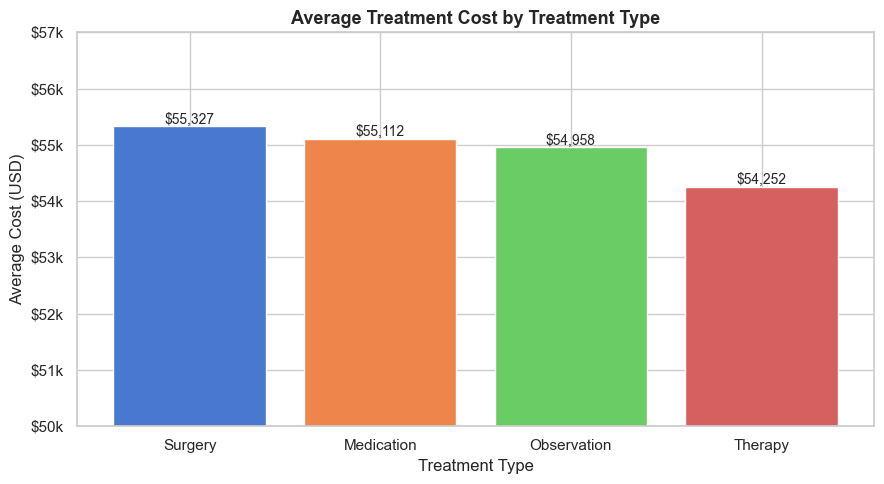

In [4]:
# Cost by treatment type — bar chart
avg_cost_tx = df.groupby('treatment_type')['treatment_cost'].mean().sort_values(ascending=False)

plt.figure(figsize=(9, 5))
bars = plt.bar(avg_cost_tx.index, avg_cost_tx.values, color=sns.color_palette('muted', len(avg_cost_tx)))
plt.title('Average Treatment Cost by Treatment Type', fontsize=13, fontweight='bold')
plt.xlabel('Treatment Type')
plt.ylabel('Average Cost (USD)')
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
plt.ylim(50000, 57000)
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
             f'${bar.get_height():,.0f}', ha='center', fontsize=10)
plt.tight_layout()
plt.savefig('../reports/charts/11_cost_by_treatment.png', dpi=120, bbox_inches='tight')
plt.show()

---
## Operational Analysis

In [5]:
print('=== OPERATIONS ===')
print(f'Overall Avg LOS: {df["length_of_stay_days"].mean():.2f} days')
print()
print('Avg LOS by Department:')
print(df.groupby('department')['length_of_stay_days'].mean().sort_values(ascending=False).round(2))
print()
print('Avg LOS by Visit Type:')
print(df.groupby('visit_type')['length_of_stay_days'].mean().sort_values(ascending=False).round(2))

=== OPERATIONS ===
Overall Avg LOS: 4.06 days

Avg LOS by Department:
department
Pediatrics         4.14
General Medicine   4.07
Neurology          4.06
Cardiology         4.03
Orthopedics        4.01
Name: length_of_stay_days, dtype: float64

Avg LOS by Visit Type:
visit_type
Emergency   4.10
Routine     4.04
Name: length_of_stay_days, dtype: float64


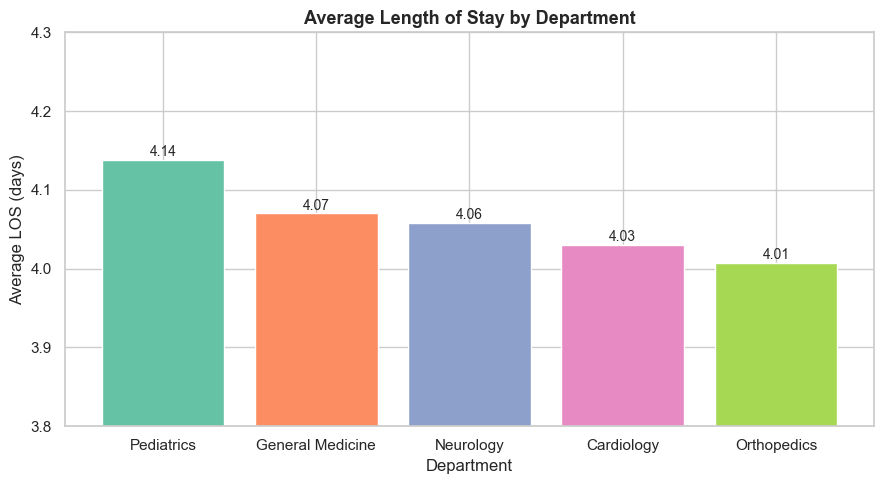

In [6]:
# Avg LOS by department — bar chart
los_dept = df.groupby('department')['length_of_stay_days'].mean().sort_values(ascending=False)

plt.figure(figsize=(9, 5))
bars = plt.bar(los_dept.index, los_dept.values, color=sns.color_palette('Set2', len(los_dept)))
plt.title('Average Length of Stay by Department', fontsize=13, fontweight='bold')
plt.xlabel('Department')
plt.ylabel('Average LOS (days)')
plt.ylim(3.8, 4.3)
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{bar.get_height():.2f}', ha='center', fontsize=10)
plt.tight_layout()
plt.savefig('../reports/charts/12_los_by_department.png', dpi=120, bbox_inches='tight')
plt.show()

---
## Risk Analysis

In [7]:
print('=== READMISSION RISK ===')
risk_counts = df['readmission_risk'].value_counts()
risk_order = ['High', 'Medium', 'Low']
for r in risk_order:
    print(f'{r}: {risk_counts[r]:,} ({risk_counts[r]/len(df)*100:.1f}%)')
print()
print('Risk % by Department (High):')
dept_risk = df[df['readmission_risk']=='High'].groupby('department').size() / df.groupby('department').size() * 100
print(dept_risk.sort_values(ascending=False).round(2))
print()
print('Avg Recovery by Risk:')
print(df.groupby('readmission_risk')['recovery_score'].mean().round(2))

=== READMISSION RISK ===
High: 176 (3.5%)
Medium: 1,822 (36.4%)
Low: 3,002 (60.0%)

Risk % by Department (High):
department
Orthopedics        3.78
Pediatrics         3.74
General Medicine   3.53
Cardiology         3.42
Neurology          3.10
dtype: float64

Avg Recovery by Risk:
readmission_risk
High     73.81
Low      74.71
Medium   74.82
Name: recovery_score, dtype: float64


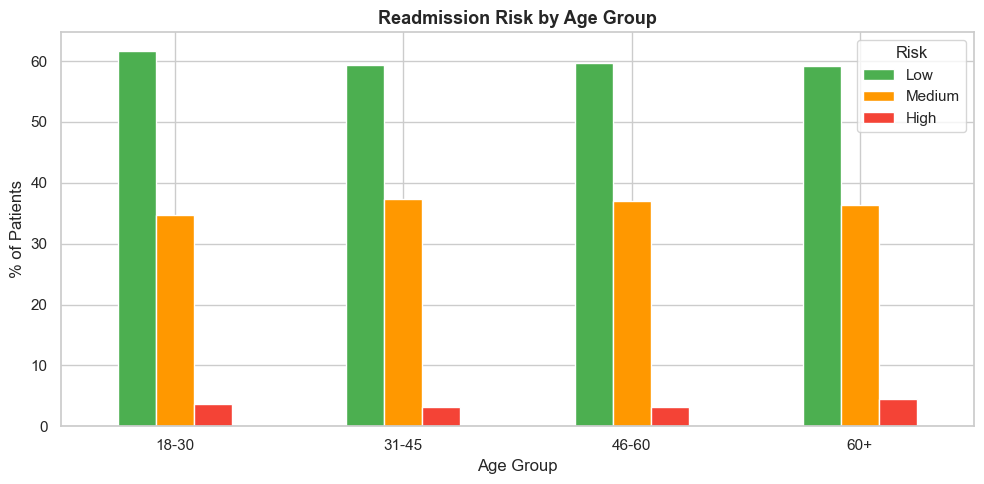

In [8]:
# Risk by age group — grouped bar
risk_age = df.groupby(['age_group', 'readmission_risk']).size().unstack(fill_value=0)
risk_age_pct = risk_age.div(risk_age.sum(axis=1), axis=0) * 100
risk_age_pct = risk_age_pct[['Low', 'Medium', 'High']]

risk_age_pct.plot(kind='bar', figsize=(10, 5),
                  color=['#4caf50', '#ff9800', '#f44336'],
                  edgecolor='white')
plt.title('Readmission Risk by Age Group', fontsize=13, fontweight='bold')
plt.xlabel('Age Group')
plt.ylabel('% of Patients')
plt.legend(title='Risk')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../reports/charts/13_risk_by_age.png', dpi=120, bbox_inches='tight')
plt.show()

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_18924\4270449363.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='readmission_risk', y='recovery_score',


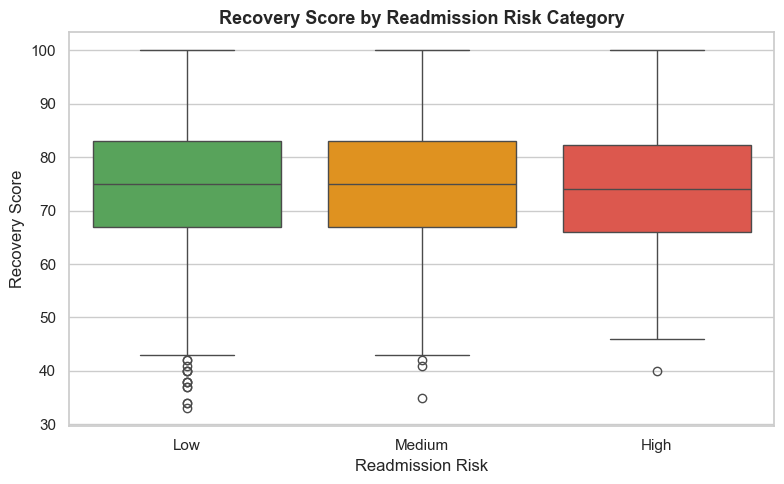

Note: Recovery scores overlap substantially across risk categories, confirming the low correlation.


In [9]:
# Recovery score by risk category
plt.figure(figsize=(8, 5))
risk_order = ['Low', 'Medium', 'High']
sns.boxplot(data=df, x='readmission_risk', y='recovery_score',
            order=risk_order, palette=['#4caf50', '#ff9800', '#f44336'])
plt.title('Recovery Score by Readmission Risk Category', fontsize=13, fontweight='bold')
plt.xlabel('Readmission Risk')
plt.ylabel('Recovery Score')
plt.tight_layout()
plt.savefig('../reports/charts/14_recovery_vs_risk.png', dpi=120, bbox_inches='tight')
plt.show()

print('Note: Recovery scores overlap substantially across risk categories, confirming the low correlation.')

---
## Summary KPI Table

In [10]:
kpis = {
    'Total Patients': f"{df['patient_id'].nunique():,}",
    'Total Visits': f"{len(df):,}",
    'Total Treatment Cost': f"${df['treatment_cost'].sum():,.0f}",
    'Avg Treatment Cost': f"${df['treatment_cost'].mean():,.0f}",
    'Avg Length of Stay': f"{df['length_of_stay_days'].mean():.2f} days",
    'Avg Recovery Score': f"{df['recovery_score'].mean():.2f}",
    'High Risk %': f"{(df['readmission_risk']=='High').sum()/len(df)*100:.1f}%",
}

for k, v in kpis.items():
    print(f'{k:<30} {v}')

Total Patients                 5,000
Total Visits                   5,000
Total Treatment Cost           $274,577,359
Avg Treatment Cost             $54,915
Avg Length of Stay             4.06 days
Avg Recovery Score             74.72
High Risk %                    3.5%
